# 01. BAMIC on Wine Reviews (benchmark-framework edition)

The original wine corpus, re-run inside the same framework as the SST-2 / IMDB /
Yelp benchmarks so all five datasets share one comparison format - now on the
**25,000 / 3,000 / 10,000 stratified subsample** (notebook 00), which keeps every
model fast while preserving the 34/66 class balance. The penalty configuration is
the June grid-search winner - **frozen GloVe, lambda_B = 0.10 (boilerplate),
lambda_S = 0.01 (stopwords), 10 epochs, MAX_LEN 100** - which on the full corpus
produced test acc 0.8620 / AUC 0.9456 / ECE 0.0706 and cleaned all metadata
contamination out of the top-word list. (Numbers here will differ slightly from
the full-data run; the June result remains the original-corpus reference.)

Two framework updates vs the June runs (both should be neutral-to-helpful):
the 2-epoch **penalty warmup** validated on IMDB/Yelp, and the standard benchmark
metric/saving cells (`final_metrics.csv`, threshold tuning, uncertainty tables).

**What to watch in the training log:** after the warmup, `bp_delta` (boilerplate)
should drop fastest, `sw_delta` next, and `content_delta` must stay well above
both - the three-way separation is the wine version of the mechanism figure.

Expect roughly **10-15 minutes on a T4** (25,000 reviews, ~195 steps/epoch).

In [25]:
# ================================================================
# 0. Check the Colab GPU
# ================================================================

# Ask the Colab runtime which GPU we were given.
gpu_info = !nvidia-smi
# Join the command output lines into one printable string.
gpu_info = '\n'.join(gpu_info)
# If the command failed, we are not connected to a GPU runtime.
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU. In Colab: Runtime -> Change runtime type -> T4 GPU.')
else:
    print(gpu_info)

Tue Aug  4 04:32:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             60W /  400W |   12114MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [26]:
# ================================================================
# 1. Check the Colab RAM
# ================================================================

# psutil reports how much system memory this runtime has.
import psutil
# Convert bytes to gigabytes for a readable number.
ram_gb = psutil.virtual_memory().total / 1e9
# Print the available RAM so we know which runtime type we received.
print('Your runtime has {:.1f} gigabytes of available RAM'.format(ram_gb))

Your runtime has 179.4 gigabytes of available RAM


In [27]:
# ================================================================
# 2. Basic imports and reproducibility
# ================================================================

# pathlib gives clean, operating-system-safe file paths.
from pathlib import Path

# random controls Python-level randomness.
import random

# re is used for simple text cleaning and tokenization.
import re

# Counter helps build the vocabulary from token frequencies.
from collections import Counter

# numpy handles numeric arrays outside PyTorch.
import numpy as np

# pandas handles CSV data tables.
import pandas as pd

# torch is the deep learning framework used across all AMIC notebooks.
import torch

# nn contains PyTorch neural-network modules.
from torch import nn

# F contains functional operations such as relu, softmax, and softplus.
import torch.nn.functional as F

# Dataset and DataLoader create mini-batches for training.
from torch.utils.data import Dataset, DataLoader

# Metrics for classification quality and calibration.
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, brier_score_loss, log_loss

# matplotlib draws simple training curves.
import matplotlib.pyplot as plt

# math is used for square roots inside the attention block.
import math

# f1_score is also used directly by the threshold-tuning cell.
from sklearn.metrics import f1_score

# This seed keeps runs as reproducible as possible; it matches the wine BAMIC notebooks.
SEED = 20260526

# Seed Python's random module.
random.seed(SEED)

# Seed NumPy's random generator.
np.random.seed(SEED)

# Seed PyTorch's CPU generator.
torch.manual_seed(SEED)

# Seed all CUDA devices if a GPU is available.
torch.cuda.manual_seed_all(SEED)

# Pick the Colab GPU when available; otherwise fall back to CPU.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print the selected device so we know what this notebook is using.
print('Using device:', DEVICE)

Using device: cuda


In [28]:
# ================================================================
# 3. BAMIC configuration for this run (all knobs live in this one cell)
# ================================================================

# Freeze (True) or fine-tune (False) the GloVe embedding matrix. Frozen matches the
# published wine runs and is the safe default for review-level corpora.
FREEZE_EMBEDDINGS = True

# Number of training epochs (10 matches the original wine runs).
ABLATION_EPOCHS = 15

# Number of attention heads in each branch (300 must be divisible by this).
NUM_HEADS = 1

# WINE-SPECIFIC: trailing-boilerplate penalty. Wine reviews end with metadata such as
# "Drink now. 5,000 cases made." - Layer 1 must not select those tokens as sentiment
# evidence. 0.10 is the preferred value from the June grid search (the run that
# produced test acc 0.8620 / AUC 0.9456 / ECE 0.0706 and drove metadata contamination
# of the top-word list from 7 words to 0).
USE_BOILERPLATE_PENALTY = True
LAMBDA_BOILERPLATE = 0.10

# Soft stopword penalty strength. 0.01 is the wine-preferred value from the same grid
# (weaker than the 0.02 used on IMDB/Yelp: wine reviews are short, and some function
# words carry aging-window structure).
USE_STOPWORD_SELECTION_PENALTY = True
LAMBDA_STOPWORD = 0.01

# Do not double-penalize a token that is both a stopword and boilerplate
# (the boilerplate penalty takes precedence, as in the original notebook).
STOPWORD_PENALTY_EXCLUDES_BOILERPLATE = True

# Penalty warmup: BOTH penalties stay OFF for this many initial epochs so Layer 1
# first learns to select words at all. This is the collapse-prevention fix validated
# on IMDB and Yelp; the original wine runs predate it (they trained cleanly anyway,
# but the warmup is now the framework standard). Set 0 to reproduce the June setup.
STOPWORD_WARMUP_EPOCHS = 2

# Learning rate for AdamW (matches every BAMIC run in the project).
BAMIC_LEARNING_RATE = 3e-4

# Maximum word tokens per review. 100 covers every review in this corpus.
MAX_LEN = 100

# Mini-batch size. 128 (not the original 256) so the 25,000-review subsample still
# gives ~195 optimizer steps per epoch - cheap insurance for the selection gate,
# which likes many small steps (the ERASER collapse happened at ~100 long-document
# steps per epoch; wine's short reviews carry a much stronger per-word signal).
BATCH_SIZE = 128

# Build a self-describing experiment name from the flags.
freeze_tag = 'frozen' if FREEZE_EMBEDDINGS else 'unfrozen'
EXPERIMENT_NAME = (f'wine_bamic_{freeze_tag}_ep{ABLATION_EPOCHS}_heads{NUM_HEADS}'
                   f'_lamB{str(LAMBDA_BOILERPLATE).replace(".", "p")}'
                   f'_lamS{str(LAMBDA_STOPWORD).replace(".", "p")}_len{MAX_LEN}')

# Print the configuration so it is recorded in the notebook output.
print('FREEZE_EMBEDDINGS      :', FREEZE_EMBEDDINGS)
print('ABLATION_EPOCHS        :', ABLATION_EPOCHS)
print('NUM_HEADS              :', NUM_HEADS)
print('LAMBDA_BOILERPLATE     :', LAMBDA_BOILERPLATE)
print('LAMBDA_STOPWORD        :', LAMBDA_STOPWORD)
print('STOPWORD_WARMUP_EPOCHS :', STOPWORD_WARMUP_EPOCHS)
print('BAMIC_LEARNING_RATE    :', BAMIC_LEARNING_RATE)
print('MAX_LEN                :', MAX_LEN, '| BATCH_SIZE:', BATCH_SIZE)
print('EXPERIMENT_NAME        :', EXPERIMENT_NAME)

FREEZE_EMBEDDINGS      : True
ABLATION_EPOCHS        : 15
NUM_HEADS              : 1
LAMBDA_BOILERPLATE     : 0.1
LAMBDA_STOPWORD        : 0.01
STOPWORD_WARMUP_EPOCHS : 2
BAMIC_LEARNING_RATE    : 0.0003
MAX_LEN                : 100 | BATCH_SIZE: 128
EXPERIMENT_NAME        : wine_bamic_frozen_ep15_heads1_lamB0p1_lamS0p01_len100


In [29]:
# ================================================================
# 4. Mount Google Drive and define project paths
# ================================================================

# Mount Google Drive so Colab can read and write project files.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

# The same Google Drive project folder used by all the benchmark notebooks.
PROJECT_DIR = Path('/content/drive/MyDrive/AMIC project')

# All wine benchmark files live inside this subfolder.
BENCH_DIR = PROJECT_DIR / 'wine_benchmark'

# The shared, prepared wine splits are stored here by notebook 00.
DATA_DIR = BENCH_DIR / 'data'

# This notebook writes all of its results into its own output folder,
# named by the configuration flags defined above.
OUTPUT_DIR = BENCH_DIR / 'outputs' / EXPERIMENT_NAME

# Create the output folder if it does not exist yet.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Print the paths so we can verify them before loading data.
print('DATA_DIR  :', DATA_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
DATA_DIR  : /content/drive/MyDrive/AMIC project/wine_benchmark/data
OUTPUT_DIR: /content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_frozen_ep15_heads1_lamB0p1_lamS0p01_len100


In [30]:
# ================================================================
# 4. Load the shared wine splits prepared by notebook 00
# ================================================================

# Stop early with a clear message if notebook 00 has not been run yet.
for name in ['wine_train.csv', 'wine_valid.csv', 'wine_test.csv']:
    if not (DATA_DIR / name).exists():
        raise FileNotFoundError(f'Missing {DATA_DIR / name}. Run 00_prepare_wine_data.ipynb first.')

# Read the three prepared splits from Drive (the train file is ~5 MB, quick).
train_df = pd.read_csv(DATA_DIR / 'wine_train.csv')
valid_df = pd.read_csv(DATA_DIR / 'wine_valid.csv')
test_df = pd.read_csv(DATA_DIR / 'wine_test.csv')

# Force the text column to string in case pandas parsed something unusually.
for df in [train_df, valid_df, test_df]:
    df['text'] = df['text'].astype(str)

# Print shapes and label balance. NOTE: unlike the other benchmarks, wine is NOT
# balanced - about 34% of reviews score 90+ - so expect a positive rate near 0.34.
print('train:', train_df.shape, '| positive rate:', round(train_df['y'].mean(), 4))
print('valid:', valid_df.shape, '| positive rate:', round(valid_df['y'].mean(), 4))
print('test :', test_df.shape, '| positive rate:', round(test_df['y'].mean(), 4))

# Show one example review (truncated for display).
print(train_df['text'].iloc[0][:300], '...')

train: (25000, 3) | positive rate: 0.342
valid: (3000, 3) | positive rate: 0.342
test : (10000, 3) | positive rate: 0.342
Offers a diffuse, medium-bodied mix of cherry cola and pie, with a touch of chicory, turning simpler on the finish. Drink now. 625 cases made. ...


In [31]:
# ================================================================
# 5. Tokenization, vocabulary, and fixed-length encoding
# ================================================================

# This regular expression keeps word-like tokens, numbers, and contractions
# such as "it's" as single tokens (same tokenizer as the wine and SST-2 notebooks).
TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")


def clean_text(text):
    """Convert raw text to a normalized lowercase string."""
    # Guard against missing values.
    if not isinstance(text, str):
        text = ''
    # Lowercase so 'Good' and 'good' share one embedding.
    text = text.lower()
    # Collapse repeated whitespace into single spaces.
    text = re.sub(r'\s+', ' ', text).strip()
    # Return the normalized string.
    return text


def tokenize(text):
    """Tokenize text into a list of lowercase word-like tokens."""
    return TOKEN_RE.findall(clean_text(text))


# MAX_LEN comes from the configuration cell above (100, the original AMIC window,
# which covers every review in this corpus completely).
print('Using MAX_LEN from the configuration cell:', MAX_LEN)

# MIN_FREQ = 2 matches the original wine AMIC/BAMIC notebooks, so the vocabulary
# (and therefore the published wine numbers) stays comparable.
MIN_FREQ = 2

# Count token frequencies over the TRAINING split only (never valid/test, to avoid leakage).
token_counts = Counter()
for text in train_df['text']:
    token_counts.update(tokenize(text))

# Index 0 is reserved for padding; index 1 is reserved for unknown words.
word_to_id = {'<PAD>': 0, '<UNK>': 1}

# Add every frequent-enough token to the vocabulary.
for word, count in token_counts.most_common():
    if count >= MIN_FREQ:
        word_to_id[word] = len(word_to_id)

# Build the reverse map for printing words back from ids.
id_to_word = {idx: word for word, idx in word_to_id.items()}

# Report the vocabulary size and the most common tokens as a sanity check.
print('Vocabulary size including PAD and UNK:', len(word_to_id))
print('Most common tokens:', token_counts.most_common(10))


def encode_text(text):
    """Convert one review into a fixed-length list of token ids."""
    # Map each token to its id, or to UNK when the token is out of vocabulary.
    ids = [word_to_id.get(tok, 1) for tok in tokenize(text)]
    # Truncate reviews that are longer than MAX_LEN.
    ids = ids[:MAX_LEN]
    # Remember the real (unpadded) length.
    length = len(ids)
    # Pad short reviews with zeros up to MAX_LEN.
    ids = ids + [0] * (MAX_LEN - len(ids))
    # Return both the ids and the real length.
    return ids, length


def encode_dataframe(df):
    """Encode a whole dataframe into id matrices, lengths, and label arrays."""
    encoded = [encode_text(t) for t in df['text']]
    x = np.array([e[0] for e in encoded], dtype=np.int64)
    lengths = np.array([e[1] for e in encoded], dtype=np.int64)
    y = df['y'].to_numpy().astype(np.float32)
    return x, lengths, y


# Encode all three splits (38k short reviews - a few seconds).
x_train, len_train, y_train = encode_dataframe(train_df)
x_valid, len_valid, y_valid = encode_dataframe(valid_df)
x_test, len_test, y_test = encode_dataframe(test_df)

# Report how much text the 256-token window truncates.
print('Share of train reviews truncated at MAX_LEN:', round((len_train == MAX_LEN).mean(), 3))

# Print the encoded shapes to confirm everything lines up.
print('x_train:', x_train.shape, 'y_train:', y_train.shape)
print('x_valid:', x_valid.shape, 'y_valid:', y_valid.shape)
print('x_test :', x_test.shape, 'y_test :', y_test.shape)

Using MAX_LEN from the configuration cell: 100
Vocabulary size including PAD and UNK: 5210
Most common tokens: [('and', 57996), ('with', 24692), ('cases', 23842), ('a', 23808), ('the', 21999), ('now', 21213), ('drink', 20745), ('made', 18466), ('of', 17692), ('through', 17657)]
Share of train reviews truncated at MAX_LEN: 0.0
x_train: (25000, 100) y_train: (25000,)
x_valid: (3000, 100) y_valid: (3000,)
x_test : (10000, 100) y_test : (10000,)


In [32]:
# ================================================================
# 6. Load GloVe 300d embeddings for our vocabulary
# ================================================================

# GloVe 6B vectors are 300-dimensional, matching the wine BAMIC setup.
EMBED_DIM = 300

# The GloVe text file lives in the shared word_embedding folder of the Drive project.
GLOVE_PATH = PROJECT_DIR / 'word_embedding' / 'glove.6B.300d.txt'

# Fail early with a clear message if the embedding file is missing.
if not GLOVE_PATH.exists():
    raise FileNotFoundError(f'GloVe file not found: {GLOVE_PATH}. '
                            'Upload glove.6B.300d.txt to the word_embedding folder in Drive.')


def build_random_embedding_matrix(vocab_size, embedding_dim):
    """Create a small random embedding matrix with a zero padding row."""
    # A fixed-seed generator keeps the random rows reproducible.
    rng = np.random.default_rng(SEED)
    # Small random values for words that GloVe does not cover.
    matrix = rng.normal(loc=0.0, scale=0.05, size=(vocab_size, embedding_dim)).astype(np.float32)
    # Row 0 is the PAD token and must stay all-zero.
    matrix[0] = 0.0
    # Return the initialized matrix.
    return matrix


def load_glove_for_vocab(glove_path, word_to_id, embedding_dim=300):
    """Load only the GloVe vectors whose words appear in our vocabulary."""
    # Start from the random matrix so uncovered words keep small random vectors.
    matrix = build_random_embedding_matrix(len(word_to_id), embedding_dim)
    # Track how many vocabulary words GloVe covers.
    found = 0
    # A set makes the membership test fast inside the file loop.
    needed_words = set(word_to_id.keys())
    # Stream the large GloVe file line by line to stay memory-friendly.
    with open(glove_path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            # Each line is: word value_1 ... value_300.
            parts = line.rstrip().split(' ')
            # Skip malformed lines defensively.
            if len(parts) != embedding_dim + 1:
                continue
            # First field is the word itself.
            word = parts[0]
            # Ignore words that are not in our vocabulary.
            if word not in needed_words:
                continue
            # Copy this word's vector into its row of the matrix.
            matrix[word_to_id[word]] = np.asarray(parts[1:], dtype=np.float32)
            # Count the successful match.
            found += 1
    # Keep the PAD row exactly zero after loading.
    matrix[0] = 0.0
    # Report the coverage so we can compare with the wine corpus (92.7% there).
    print(f'Loaded {found:,} / {len(word_to_id):,} vocabulary vectors from GloVe '
          f'({found / max(1, len(word_to_id)):.1%}).')
    # Return the matrix as a torch tensor ready for nn.Embedding.
    return torch.tensor(matrix, dtype=torch.float32)


# Build the embedding matrix for this vocabulary.
embedding_matrix = load_glove_for_vocab(GLOVE_PATH, word_to_id, EMBED_DIM)

# Confirm the final shape: (vocabulary size, embedding dimension).
print('embedding_matrix:', tuple(embedding_matrix.shape))

Loaded 4,988 / 5,210 vocabulary vectors from GloVe (95.7%).
embedding_matrix: (5210, 300)


In [33]:
# ================================================================
# 8. Stopword and boilerplate penalty masks (wine-specific)
# ================================================================

# Common English function words that should not dominate word-level sentiment
# explanations - the SAME conservative list as the original wine notebook
# (no contraction fragments needed: the tokenizer keeps "it's" as one token).
STOPWORD_PENALTY_WORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'if', 'then', 'else', 'when', 'while',
    'as', 'of', 'in', 'on', 'at', 'by', 'for', 'from', 'to', 'into', 'onto',
    'with', 'without', 'within', 'over', 'under', 'above', 'below', 'up', 'down',
    'out', 'off', 'through', 'during', 'before', 'after', 'between', 'among',
    'about', 'against', 'this', 'that', 'these', 'those', 'there', 'here',
    'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
    'do', 'does', 'did', 'can', 'could', 'should', 'would', 'will', 'may',
    'might', 'must', 'not', 'no', 'nor', 'so', 'than', 'too', 'very', 'some',
    'any', 'all', 'each', 'few', 'more', 'most', 'other', 'such', 'only',
    'own', 'same', 'both', 'either', 'neither', 'it', 'its', 'itself', 'they',
    'them', 'their', 'theirs', 'he', 'him', 'his', 'she', 'her', 'hers', 'we',
    'us', 'our', 'ours', 'you', 'your', 'yours', 'i', 'me', 'my', 'mine',
    'who', 'whom', 'whose', 'which', 'what', 'where', 'why', 'how', 'because',
    'also', 'just', 'even', 'still', 'already', 'yet', 'now',
}

# These patterns match ONLY trailing wine-review metadata, applied repeatedly from
# the end of the review - "drink" inside a real sentence is never touched.
# (Identical to the original Bayesian_AMIC_WD_clean notebook.)
WINE_TRAILING_BOILERPLATE_PATTERNS = [
    # Trailing production/import metadata, e.g. "1,200 cases made, 300 cases imported."
    re.compile(r"\s*\d[\d,]*\s+cases\s+(?:made|imported)"
               r"(?:,\s*\d[\d,]*\s+cases\s+(?:made|imported))*\.?\s*$", flags=re.I),
    # Trailing tasting-note metadata.
    re.compile(r"\s*tasted twice,\s*with consistent notes\.?\s*$", flags=re.I),
    # Trailing drinking-window metadata.
    re.compile(r"\s*(?:drink now|drink now through \d{4}|drink through \d{4}|"
               r"best from \d{4} through \d{4}|from \d{4} through \d{4})\.?\s*$", flags=re.I),
]


def sentiment_token_count(text):
    """Number of leading tokens that are real sentiment text (the rest is boilerplate)."""
    # Normalize exactly like the tokenizer does.
    lowered = clean_text(text)
    # Strip trailing metadata patterns repeatedly until nothing more matches.
    stripped = lowered
    changed = True
    while changed:
        changed = False
        for pattern in WINE_TRAILING_BOILERPLATE_PATTERNS:
            new_text = pattern.sub('', stripped).strip()
            if new_text != stripped:
                stripped = re.sub(r'\s+', ' ', new_text).strip()
                changed = True
    # The boilerplate is whatever tokens remain AFTER the stripped prefix.
    return len(tokenize(stripped))


def build_penalty_masks(df, x_ids):
    """Build aligned stopword and boilerplate 0/1 masks for one split."""
    sw = np.zeros_like(x_ids, dtype=np.float32)
    bp = np.zeros_like(x_ids, dtype=np.float32)
    # Walk over every review in the dataframe.
    for i, text in enumerate(df['text']):
        # Tokens kept by the model are the first MAX_LEN tokens of the full text.
        n_sentiment = sentiment_token_count(text)
        for j in range(x_ids.shape[1]):
            # Token id 0 is padding; padding only appears at the end, so stop there.
            if x_ids[i, j] == 0:
                break
            word = id_to_word.get(int(x_ids[i, j]), '')
            # Positions past the sentiment prefix are trailing boilerplate.
            if j >= n_sentiment:
                bp[i, j] = 1.0
            # Stopword positions (boilerplate wins when both apply - handled in the loss).
            elif word in STOPWORD_PENALTY_WORDS:
                sw[i, j] = 1.0
    return sw, bp


# Build the masks for all three splits (38k short reviews - well under a minute).
sw_train, bp_train = build_penalty_masks(train_df, x_train)
sw_valid, bp_valid = build_penalty_masks(valid_df, x_valid)
sw_test, bp_test = build_penalty_masks(test_df, x_test)

# Report how many positions each penalty touches (boilerplate should be a small tail).
for name, sw, bp in [('train', sw_train, bp_train), ('valid', sw_valid, bp_valid),
                     ('test', sw_test, bp_test)]:
    print(f'{name}: stopword positions={int(sw.sum()):,} | boilerplate positions={int(bp.sum()):,}')

train: stopword positions=218,985 | boilerplate positions=167,940
valid: stopword positions=26,442 | boilerplate positions=20,014
test: stopword positions=87,315 | boilerplate positions=66,938


In [34]:
# ================================================================
# 9. Dataset and DataLoader (three masks per review)
# ================================================================

class AMICTextDataset(Dataset):
    """Dataset wrapper: token ids, label, length, stopword mask, boilerplate mask."""

    def __init__(self, x, y, lengths, stopword_masks, boilerplate_masks):
        # Token ids as long tensors (required by nn.Embedding).
        self.x = torch.tensor(x, dtype=torch.long)
        # Labels as float tensors (required by BCEWithLogitsLoss).
        self.y = torch.tensor(y, dtype=torch.float32)
        # Real (unpadded) review lengths.
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        # Stopword penalty masks (1 = penalized position).
        self.stopword_masks = torch.tensor(stopword_masks, dtype=torch.float32)
        # Boilerplate penalty masks (1 = trailing-metadata position).
        self.boilerplate_masks = torch.tensor(boilerplate_masks, dtype=torch.float32)

    def __len__(self):
        # The dataset length is the number of reviews.
        return self.x.size(0)

    def __getitem__(self, idx):
        # Return one example as a dictionary of tensors.
        return {
            'input_ids': self.x[idx],
            'label': self.y[idx],
            'length': self.lengths[idx],
            'stopword_mask': self.stopword_masks[idx],
            'boilerplate_mask': self.boilerplate_masks[idx],
        }


# BATCH_SIZE comes from the configuration cell (128 on the 25k subsample).
print('Using BATCH_SIZE from the configuration cell:', BATCH_SIZE)

# Build the three split datasets.
train_ds = AMICTextDataset(x_train, y_train, len_train, sw_train, bp_train)
valid_ds = AMICTextDataset(x_valid, y_valid, len_valid, sw_valid, bp_valid)
test_ds = AMICTextDataset(x_test, y_test, len_test, sw_test, bp_test)

# Build the mini-batch loaders; only training data is shuffled.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Print the number of batches per split as a sanity check.
print('train batches:', len(train_loader))
print('valid batches:', len(valid_loader))
print('test batches :', len(test_loader))

Using BATCH_SIZE from the configuration cell: 128
train batches: 196
valid batches: 24
test batches : 79


In [35]:
# ================================================================
# 9. Bayesian linear layer for b and beta (identical to the wine notebook)
# ================================================================

class BayesianLinear(nn.Module):
    """Linear layer with a factorized Gaussian variational posterior."""

    def __init__(self, in_features, out_features=1, prior_sigma=1.0, init_rho=-5.0):
        # Initialize nn.Module.
        super().__init__()
        # Save dimensions.
        self.in_features = in_features
        self.out_features = out_features
        # Learn posterior means for weights.
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        # Learn unconstrained posterior rho values for weights.
        self.weight_rho = nn.Parameter(torch.full((out_features, in_features), float(init_rho)))
        # Learn posterior means for biases.
        self.bias_mu = nn.Parameter(torch.zeros(out_features))
        # Learn unconstrained posterior rho values for biases.
        self.bias_rho = nn.Parameter(torch.full((out_features,), float(init_rho)))
        # Store the prior standard deviation as a non-trainable tensor.
        self.register_buffer('prior_sigma', torch.tensor(float(prior_sigma)))
        # Initialize means with small noise so b and beta can learn immediately.
        nn.init.normal_(self.weight_mu, mean=0.0, std=0.02)
        # Keep bias means at zero.
        nn.init.zeros_(self.bias_mu)

    @property
    def weight_sigma(self):
        # Convert rho to a positive standard deviation with softplus.
        return F.softplus(self.weight_rho) + 1e-8

    @property
    def bias_sigma(self):
        # Convert rho to a positive standard deviation with softplus.
        return F.softplus(self.bias_rho) + 1e-8

    def sample_parameters(self, sample=True):
        """Return one sampled weight and bias, or the posterior means."""
        # Use posterior means for deterministic evaluation when sample=False.
        if not sample:
            return self.weight_mu, self.bias_mu
        # Draw standard normal noise for weights.
        eps_w = torch.randn_like(self.weight_mu)
        # Draw standard normal noise for biases.
        eps_b = torch.randn_like(self.bias_mu)
        # Reparameterize weights: w = mu + sigma * eps.
        weight = self.weight_mu + self.weight_sigma * eps_w
        # Reparameterize biases the same way.
        bias = self.bias_mu + self.bias_sigma * eps_b
        # Return the sampled parameters.
        return weight, bias

    def forward(self, x, sample=True):
        """Apply the sampled (or mean) linear map to x."""
        # x can have shape [B, D] or [B, T, D].
        weight, bias = self.sample_parameters(sample=sample)
        # F.linear supports leading dimensions automatically.
        return F.linear(x, weight, bias)

    def kl(self):
        """Closed-form KL divergence KL(q(w)||p(w)) for normal q and normal prior."""
        # Get the posterior standard deviations.
        w_sigma = self.weight_sigma
        b_sigma = self.bias_sigma
        # Get the prior standard deviation.
        p_sigma = self.prior_sigma
        # KL contribution of every weight.
        kl_w = torch.log(p_sigma / w_sigma) + (w_sigma.pow(2) + self.weight_mu.pow(2)) / (2.0 * p_sigma.pow(2)) - 0.5
        # KL contribution of every bias.
        kl_b = torch.log(p_sigma / b_sigma) + (b_sigma.pow(2) + self.bias_mu.pow(2)) / (2.0 * p_sigma.pow(2)) - 0.5
        # Sum over all parameters.
        return kl_w.sum() + kl_b.sum()

In [36]:
# ================================================================
# 10. Self-attention block (identical to the wine notebook)
# ================================================================

class SelfAttention(nn.Module):
    """Multi-head self-attention with an optional output projection."""

    def __init__(self, emb_dim, num_heads=1, output_dim=None, dropout=0.10):
        # Initialize nn.Module.
        super().__init__()
        # The embedding dimension must divide evenly across heads.
        assert emb_dim % num_heads == 0, 'emb_dim must be divisible by num_heads'
        # Store dimensions.
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.head_dim = emb_dim // num_heads
        # Project inputs to queries.
        self.to_q = nn.Linear(emb_dim, emb_dim, bias=False)
        # Project inputs to keys.
        self.to_k = nn.Linear(emb_dim, emb_dim, bias=False)
        # Project inputs to values.
        self.to_v = nn.Linear(emb_dim, emb_dim, bias=False)
        # Mix attention heads back together.
        self.unify = nn.Linear(emb_dim, emb_dim)
        # Optionally reduce the output dimension.
        self.project = nn.Linear(emb_dim, output_dim) if output_dim is not None else nn.Identity()
        # Drop attention weights and output features lightly.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        """Run self-attention over x = [B, T, E]; pad_mask marks real tokens with True."""
        # Read batch size, sequence length, and embedding size.
        B, T, E = x.shape
        # Project to queries, keys, and values.
        q = self.to_q(x)
        k = self.to_k(x)
        v = self.to_v(x)
        # Reshape to [B, H, T, head_dim] for multi-head attention.
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        # Compute scaled dot-product attention scores.
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # Mask padded key positions so real tokens do not attend to padding.
        if pad_mask is not None:
            key_mask = pad_mask[:, None, None, :]
            scores = scores.masked_fill(~key_mask, -1e9)
        # Normalize the scores across key positions.
        attn = F.softmax(scores, dim=-1)
        # Apply dropout to the attention weights.
        attn = self.dropout(attn)
        # Compute the weighted sum of values.
        out = torch.matmul(attn, v)
        # Merge the heads back to [B, T, E].
        out = out.transpose(1, 2).contiguous().view(B, T, E)
        # Mix the heads with a linear layer.
        out = self.unify(out)
        # Zero the padded query positions after attention.
        if pad_mask is not None:
            out = out * pad_mask.unsqueeze(-1).float()
        # Optionally project to a reduced dimension.
        out = self.project(out)
        # Return the contextual token features.
        return out

In [37]:
# ================================================================
# 11. Bayesian AMIC-WD model (identical to the wine notebook)
# ================================================================

class BayesianAMICWD(nn.Module):
    """Bayesian AMIC with uncertainty for word selection and word sentiment."""

    def __init__(self, embedding_matrix, hidden_dim=300, num_heads=1,
                 prior_sigma_b=1.0, prior_sigma_beta=1.0, init_rho=-5.0,
                 dropout=0.10, freeze_embeddings=True, selection_activation='sigmoid'):
        # Initialize nn.Module.
        super().__init__()
        # Only the two activations studied in the wine experiments are allowed.
        valid_selection_activations = {'sigmoid', 'softplus01'}
        if selection_activation not in valid_selection_activations:
            raise ValueError(f'selection_activation must be one of {valid_selection_activations}')
        # Store the hidden width and the chosen activation.
        self.hidden_dim = hidden_dim
        self.selection_activation = selection_activation
        # Frozen pretrained embeddings keep the interpretation anchored to GloVe space.
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze_embeddings, padding_idx=0)
        # Layer 1 branch: contextual features for word SELECTION.
        self.attn_p = SelfAttention(hidden_dim, num_heads=num_heads, output_dim=hidden_dim, dropout=dropout)
        self.norm_p = nn.LayerNorm(hidden_dim)
        # Bayesian coefficient b for the selection logit.
        self.b_layer = BayesianLinear(hidden_dim, out_features=1, prior_sigma=prior_sigma_b, init_rho=init_rho)
        # Layer 2 branch: contextual features for word SENTIMENT.
        self.attn_l = SelfAttention(hidden_dim, num_heads=num_heads, output_dim=hidden_dim, dropout=dropout)
        self.norm_l = nn.LayerNorm(hidden_dim)
        # Bayesian coefficient beta for the sentiment score.
        self.beta_layer = BayesianLinear(hidden_dim, out_features=1, prior_sigma=prior_sigma_beta, init_rho=init_rho)
        # Shared dropout module.
        self.dropout = nn.Dropout(dropout)

    def selection_probability(self, u):
        """Map Layer 1 logits to a soft selection probability in (0, 1)."""
        # The AMIC default: a plain sigmoid.
        if self.selection_activation == 'sigmoid':
            return torch.sigmoid(u)
        # The monotone Softplus-based alternative studied in the activation check.
        if self.selection_activation == 'softplus01':
            positive_score = F.softplus(u)
            return positive_score / (1.0 + positive_score)
        # Defensive error for anything else.
        raise ValueError(f'Unsupported selection activation: {self.selection_activation}')

    def forward(self, input_ids, sample=True):
        """One forward pass = one posterior sample of (b, beta)."""
        # True for real tokens, False for padding (PAD id is 0).
        pad_mask = input_ids.ne(0)
        # Number of real tokens per sentence, never below 1.
        valid_counts = pad_mask.sum(dim=1).clamp_min(1).float()
        # Look up the frozen embeddings.
        x = self.embedding(input_ids)

        # ----- Layer 1: Bayesian word-selection branch -----
        # Contextualize the embeddings for the selection decision.
        a_p = self.attn_p(x, pad_mask=pad_mask)
        # Normalize and regularize the features.
        a_p = self.norm_p(a_p)
        a_p = self.dropout(a_p)
        # Selection logit u_ij from one sample of b.
        u = self.b_layer(a_p, sample=sample).squeeze(-1)
        # Selection probability delta_ij, zeroed on padding.
        delta = self.selection_probability(u) * pad_mask.float()

        # ----- Layer 2: Bayesian word-sentiment branch -----
        # Contextualize the embeddings for the sentiment score.
        a_l = self.attn_l(x, pad_mask=pad_mask)
        # Normalize and regularize the features.
        a_l = self.norm_l(a_l)
        a_l = self.dropout(a_l)
        # Raw sentiment score r_ij from one sample of beta, zeroed on padding.
        raw_word_sentiment = self.beta_layer(a_l, sample=sample).squeeze(-1)
        raw_word_sentiment = raw_word_sentiment * pad_mask.float()

        # ----- AMIC gate and document aggregation -----
        # Word contribution Z_ij = delta_ij * r_ij.
        word_logit = delta * raw_word_sentiment
        # Document logit = average word contribution over real tokens.
        doc_logit = word_logit.sum(dim=1) / valid_counts
        # Document probability through a sigmoid.
        doc_prob = torch.sigmoid(doc_logit)

        # ----- AMIC regularizers, normalized by sentence length -----
        # p1 pushes delta toward 0 or 1 (binary selection).
        p1_binary = (torch.sqrt(delta * (1.0 - delta) + 1e-8) * pad_mask.float()).sum(dim=1) / valid_counts
        # p2 encourages sparse selection (few sentiment words).
        p2_sparse = delta.sum(dim=1) / valid_counts
        # p3 stabilizes the raw sentiment magnitude.
        p3_stable = torch.sqrt((raw_word_sentiment.pow(2) * pad_mask.float()).sum(dim=1) / valid_counts + 1e-8)

        # Return everything needed by the loss and the uncertainty analysis.
        return {
            'doc_logit': doc_logit,
            'doc_prob': doc_prob,
            'word_logit': word_logit,
            'raw_word_sentiment': raw_word_sentiment,
            'delta': delta,
            'u': u,
            'pad_mask': pad_mask,
            'p1_binary': p1_binary,
            'p2_sparse': p2_sparse,
            'p3_stable': p3_stable,
        }

    def kl(self):
        """Return the total KL from q(b) and q(beta)."""
        return self.b_layer.kl() + self.beta_layer.kl()

In [38]:
# ================================================================
# Metric helpers (identical to the wine BAMIC notebook, for fair comparison)
# ================================================================

def binary_metrics_from_probs(probs, labels, threshold=0.5):
    """Compute common binary metrics from predicted positive-class probabilities."""
    # Turn probabilities into hard 0/1 predictions at the given threshold.
    pred = (probs >= threshold).astype(int)
    # Fraction of documents classified correctly.
    acc = accuracy_score(labels, pred)
    # Harmonic mean of precision and recall for the positive class.
    f1 = f1_score(labels, pred, zero_division=0)
    # Threshold-free ranking quality; needs both classes present.
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) == 2 else np.nan
    # Mean squared error between probabilities and true labels.
    brier = brier_score_loss(labels, probs)
    # Negative log-likelihood of the true labels under the predicted probabilities.
    nll = log_loss(labels, np.clip(probs, 1e-7, 1 - 1e-7), labels=[0, 1])
    # Return everything in one dictionary.
    return {'acc': acc, 'f1': f1, 'auc': auc, 'brier': brier, 'nll': nll}


def expected_calibration_error(probs, labels, n_bins=10):
    """Compute a simple expected calibration error (ECE)."""
    # Create equally spaced probability bins between 0 and 1.
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    # Accumulate the weighted calibration gap here.
    ece = 0.0
    # Loop over each bin edge pair.
    for lo, hi in zip(bins[:-1], bins[1:]):
        # Include the right edge for the final bin.
        if hi == 1.0:
            mask = (probs >= lo) & (probs <= hi)
        else:
            mask = (probs >= lo) & (probs < hi)
        # Skip bins that contain no predictions.
        if not np.any(mask):
            continue
        # Average predicted probability inside this bin.
        conf = probs[mask].mean()
        # Empirical positive rate inside this bin.
        acc = labels[mask].mean()
        # Weight the |confidence - accuracy| gap by the bin frequency.
        ece += np.abs(conf - acc) * mask.mean()
    # Return the scalar ECE value.
    return float(ece)

In [39]:
# ================================================================
# 12. Loss, penalties, and training configuration
# ================================================================

# AMIC regularizer weights (identical to the baseline BAMIC run).
LAMBDA_P1 = 0.01
LAMBDA_P2 = 0.01
LAMBDA_P3 = 0.001

# Overall KL multiplier.
KL_BETA = 1.0

# Number of epochs used to gradually turn the KL term on (avoids early posterior collapse).
KL_ANNEAL_EPOCHS = 5

# Monte Carlo samples per training batch (1 is enough with the reparameterization trick).
TRAIN_MC_SAMPLES = 1

# Monte Carlo samples for per-epoch validation summaries.
EVAL_MC_SAMPLES = 20

# Learning rate comes from the configuration cell.
LEARNING_RATE = BAMIC_LEARNING_RATE
WEIGHT_DECAY = 1e-4

# Number of training epochs comes from the ablation configuration cell.
EPOCHS = ABLATION_EPOCHS

# Class weighting compensates for label imbalance - wine is ~34% positive,
# so this weight will be ~1.9 (unlike the balanced benchmarks where it was ~1).
n_pos = float(y_train.sum())
n_neg = float(len(y_train) - y_train.sum())
pos_weight = torch.tensor([n_neg / max(1.0, n_pos)], dtype=torch.float32, device=DEVICE)

# Logits-based binary cross-entropy is numerically stable.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Print the class weight so it is recorded in the output.
print('pos_weight:', float(pos_weight.item()), '| EPOCHS:', EPOCHS)


def kl_anneal_factor(epoch):
    """Linearly increase the KL weight during the first KL_ANNEAL_EPOCHS epochs."""
    return min(1.0, float(epoch) / float(max(1, KL_ANNEAL_EPOCHS)))


def compute_boilerplate_penalty(out, boilerplate_mask):
    """WINE-SPECIFIC: push Layer 1 selection logits toward 0 on trailing metadata."""
    # Only penalize real (non-padding) boilerplate positions.
    mask = boilerplate_mask.float() * out['pad_mask'].float()
    # Avoid division by zero when a batch has no boilerplate.
    denom = mask.sum().clamp_min(1.0)
    # The penalty target is "not selected", i.e. a selection label of 0.
    target = torch.zeros_like(out['u'])
    # Binary cross-entropy on the selection logits, computed per position.
    selection_bce = F.binary_cross_entropy_with_logits(out['u'], target, reduction='none')
    # Average the penalty over boilerplate positions only.
    penalty = (selection_bce * mask).sum() / denom
    # Diagnostic: mean selection probability on boilerplate positions.
    boilerplate_delta = (out['delta'] * mask).sum() / denom
    # Return the penalty and its diagnostic.
    return penalty, boilerplate_delta


def compute_stopword_penalty(out, stopword_mask, boilerplate_mask):
    """Softly push Layer 1 selection logits toward 0 on stopword positions."""
    # Only penalize real (non-padding) stopword positions.
    pad_mask = out['pad_mask'].float()
    sw_mask = stopword_mask.float() * pad_mask
    # Never double-penalize: boilerplate positions are handled by lambda_B alone.
    if STOPWORD_PENALTY_EXCLUDES_BOILERPLATE:
        sw_mask = sw_mask * (1.0 - boilerplate_mask.float() * pad_mask)
    # Avoid division by zero when a batch has no stopwords.
    denom = sw_mask.sum().clamp_min(1.0)
    # The penalty target is "not selected", i.e. a selection label of 0.
    target = torch.zeros_like(out['u'])
    # Binary cross-entropy on the selection logits, computed per position.
    selection_bce = F.binary_cross_entropy_with_logits(out['u'], target, reduction='none')
    # Average the penalty over stopword positions only.
    penalty = (selection_bce * sw_mask).sum() / denom
    # Diagnostic: mean selection probability on stopword positions.
    stopword_delta = (out['delta'] * sw_mask).sum() / denom
    # Diagnostic: mean selection probability on content positions
    # (neither stopword nor boilerplate).
    content_mask = pad_mask * (1.0 - sw_mask) * (1.0 - boilerplate_mask.float() * pad_mask)
    content_denom = content_mask.sum().clamp_min(1.0)
    content_delta = (out['delta'] * content_mask).sum() / content_denom
    # Return the penalty and both diagnostics.
    return penalty, stopword_delta, content_delta


def compute_loss(model, batch, epoch, n_train, train_mc_samples=1):
    """Compute the Monte Carlo ELBO-style loss for one batch."""
    # Move the batch tensors to the GPU.
    input_ids = batch['input_ids'].to(DEVICE)
    y = batch['label'].to(DEVICE)
    stopword_mask = batch['stopword_mask'].to(DEVICE)
    boilerplate_mask = batch['boilerplate_mask'].to(DEVICE)
    # Accumulate per-sample values here.
    nll_values, p1_values, p2_values, p3_values = [], [], [], []
    sw_penalty_values, sw_delta_values, content_delta_values = [], [], []
    bp_penalty_values, bp_delta_values = [], []
    # Draw one or more posterior samples per batch.
    for _ in range(train_mc_samples):
        # One forward pass = one sample of (b, beta).
        out = model(input_ids, sample=True)
        # Data-fit term: weighted binary cross-entropy on the document logit.
        nll_values.append(criterion(out['doc_logit'], y))
        # AMIC regularizers averaged over the batch.
        p1_values.append(out['p1_binary'].mean())
        p2_values.append(out['p2_sparse'].mean())
        p3_values.append(out['p3_stable'].mean())
        # Soft stopword penalty and its diagnostics (excludes boilerplate positions).
        sw_penalty, sw_delta, content_delta = compute_stopword_penalty(out, stopword_mask, boilerplate_mask)
        sw_penalty_values.append(sw_penalty)
        sw_delta_values.append(sw_delta)
        content_delta_values.append(content_delta)
        # WINE-SPECIFIC: boilerplate penalty and its diagnostic.
        bp_penalty, bp_delta = compute_boilerplate_penalty(out, boilerplate_mask)
        bp_penalty_values.append(bp_penalty)
        bp_delta_values.append(bp_delta)
    # Average each term over the Monte Carlo samples.
    nll = torch.stack(nll_values).mean()
    p1 = torch.stack(p1_values).mean()
    p2 = torch.stack(p2_values).mean()
    p3 = torch.stack(p3_values).mean()
    sw_penalty = torch.stack(sw_penalty_values).mean()
    sw_delta = torch.stack(sw_delta_values).mean()
    content_delta = torch.stack(content_delta_values).mean()
    bp_penalty = torch.stack(bp_penalty_values).mean()
    bp_delta = torch.stack(bp_delta_values).mean()
    # KL between the variational posteriors and the priors.
    kl = model.kl()
    # Scale the KL by the training-set size (minibatch ELBO convention).
    kl_scaled = kl / float(n_train)
    # Anneal the KL weight during the early epochs.
    kl_weight = KL_BETA * kl_anneal_factor(epoch)
    # Penalty warmup: BOTH selection penalties stay OFF for the first
    # STOPWORD_WARMUP_EPOCHS epochs so Layer 1 first learns to select words
    # (the collapse-prevention fix validated on IMDB and Yelp).
    if USE_STOPWORD_SELECTION_PENALTY and epoch > STOPWORD_WARMUP_EPOCHS:
        stopword_weight = LAMBDA_STOPWORD
    else:
        stopword_weight = 0.0
    if USE_BOILERPLATE_PENALTY and epoch > STOPWORD_WARMUP_EPOCHS:
        boilerplate_weight = LAMBDA_BOILERPLATE
    else:
        boilerplate_weight = 0.0
    # Assemble the full training objective.
    loss = (nll
            + kl_weight * kl_scaled
            + LAMBDA_P1 * p1
            + LAMBDA_P2 * p2
            + LAMBDA_P3 * p3
            + stopword_weight * sw_penalty
            + boilerplate_weight * bp_penalty)
    # Return the loss and a log dictionary of scalar components.
    return loss, {
        'nll': float(nll.detach().cpu()),
        'kl_scaled': float(kl_scaled.detach().cpu()),
        'p1': float(p1.detach().cpu()),
        'p2': float(p2.detach().cpu()),
        'p3': float(p3.detach().cpu()),
        'stopword_penalty': float(sw_penalty.detach().cpu()),
        'stopword_delta': float(sw_delta.detach().cpu()),
        'boilerplate_delta': float(bp_delta.detach().cpu()),
        'content_delta': float(content_delta.detach().cpu()),
    }

pos_weight: 1.9239766597747803 | EPOCHS: 15


In [40]:
# ================================================================
# 13. Posterior prediction for document-level uncertainty
# ================================================================

@torch.no_grad()
def posterior_predict_loader(model, loader, n_samples=20):
    """Collect document-level posterior predictive summaries for a loader."""
    # Put the model in eval mode (turns dropout off).
    model.eval()
    # Store probability samples per batch, and the labels.
    all_prob_samples, all_labels = [], []
    # Loop over mini-batches.
    for batch in loader:
        # Move token ids to the GPU.
        input_ids = batch['input_ids'].to(DEVICE)
        # Keep labels on the CPU.
        all_labels.append(batch['label'].cpu())
        # Draw repeated posterior samples for this batch.
        batch_samples = []
        for _ in range(n_samples):
            # sample=True draws a fresh (b, beta) each time.
            out = model(input_ids, sample=True)
            # Save the document probabilities for this sample.
            batch_samples.append(out['doc_prob'].detach().cpu())
        # Stack to [S, batch_size].
        all_prob_samples.append(torch.stack(batch_samples, dim=0))
    # Concatenate along the document dimension to [S, N].
    prob_samples = torch.cat(all_prob_samples, dim=1).numpy()
    # Concatenate labels to [N].
    labels = torch.cat(all_labels).numpy().astype(int)
    # Posterior predictive mean per document.
    p_mean = prob_samples.mean(axis=0)
    # Posterior predictive variance per document.
    p_var = prob_samples.var(axis=0)
    # 95% credible interval bounds.
    ci_lo = np.quantile(prob_samples, 0.025, axis=0)
    ci_hi = np.quantile(prob_samples, 0.975, axis=0)
    # Predictive entropy of the mean probability.
    eps = 1e-12
    p_clip = np.clip(p_mean, eps, 1 - eps)
    entropy = -(p_clip * np.log(p_clip) + (1 - p_clip) * np.log(1 - p_clip))
    # Expected entropy of the individual samples.
    s_clip = np.clip(prob_samples, eps, 1 - eps)
    expected_entropy = -(s_clip * np.log(s_clip) + (1 - s_clip) * np.log(1 - s_clip)).mean(axis=0)
    # BALD = mutual information between the prediction and the parameters.
    bald = entropy - expected_entropy
    # Fraction of posterior samples voting for class 1.
    prob1 = (prob_samples >= 0.5).mean(axis=0)
    # Assemble one tidy row per document.
    result = pd.DataFrame({
        'y_true': labels,
        'p_mean': p_mean,
        'ci95_lo': ci_lo,
        'ci95_hi': ci_hi,
        'ci_width': ci_hi - ci_lo,
        'var': p_var,
        'entropy': entropy,
        'bald': bald,
        'prob1': prob1,
        'label_by_mean': (p_mean >= 0.5).astype(int),
    })
    # Return the summary table and the raw samples.
    return result, prob_samples

Trainable parameters: 903604
Epoch 01 | loss=0.6167 | val_acc=0.8357 | val_auc=0.9222 | sw_delta=0.8304 | bp_delta=0.8301 | content_delta=0.8302 | val_ece=0.0443
Epoch 02 | loss=0.5145 | val_acc=0.8383 | val_auc=0.9284 | sw_delta=0.9992 | bp_delta=0.9992 | content_delta=0.9992 | val_ece=0.0611
Epoch 03 | loss=0.5928 | val_acc=0.8077 | val_auc=0.9245 | sw_delta=0.2090 | bp_delta=0.1837 | content_delta=0.7414 | val_ece=0.1323
Epoch 04 | loss=0.5434 | val_acc=0.8350 | val_auc=0.9327 | sw_delta=0.0377 | bp_delta=0.0114 | content_delta=0.8971 | val_ece=0.0909
Epoch 05 | loss=0.5496 | val_acc=0.8380 | val_auc=0.9346 | sw_delta=0.0341 | bp_delta=0.0055 | content_delta=0.8934 | val_ece=0.0778
Epoch 06 | loss=0.5470 | val_acc=0.8440 | val_auc=0.9335 | sw_delta=0.0231 | bp_delta=0.0036 | content_delta=0.8958 | val_ece=0.0653
Epoch 07 | loss=0.5345 | val_acc=0.8473 | val_auc=0.9355 | sw_delta=0.0156 | bp_delta=0.0027 | content_delta=0.8964 | val_ece=0.0524
Epoch 08 | loss=0.5255 | val_acc=0.8490 

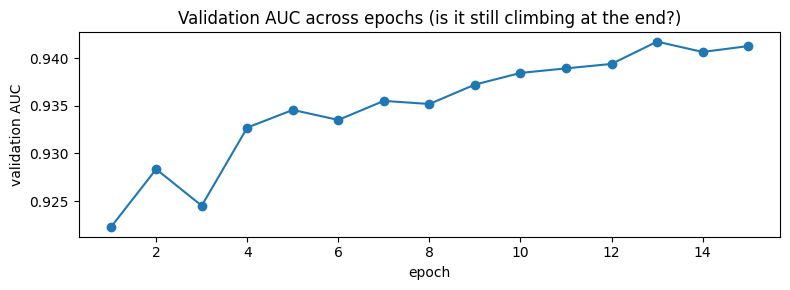

,epoch,train_loss,train_nll,train_kl_scaled,stopword_delta,boilerplate_delta,content_delta,val_acc,val_f1,val_auc,val_ece
0,1,0.616722,0.583671,0.108325,0.830386,0.830077,0.830172,0.835667,0.772497,0.922248,0.044338
1,2,0.514547,0.458069,0.107965,0.999182,0.999179,0.999179,0.838333,0.785303,0.928353,0.061094
2,3,0.592794,0.467722,0.107607,0.208999,0.183716,0.741410,0.807667,0.767057,0.924523,0.132265
3,4,0.543375,0.442493,0.107352,0.037689,0.011394,0.897072,0.835000,0.788732,0.932708,0.090880
4,5,0.549597,0.428692,0.106972,0.034063,0.005529,0.893433,0.838000,0.788143,0.934561,0.077756
5,6,0.546965,0.426957,0.106500,0.023070,0.003588,0.895812,0.844000,0.793469,0.933511,0.065301
6,7,0.534515,0.415128,0.105986,0.015592,0.002730,0.896385,0.847333,0.792196,0.935508,0.052418
7,8,0.525501,0.406273,0.105429,0.020587,0.002567,0.893884,0.849000,0.787024,0.935183,0.043159
8,9,0.518830,0.399952,0.104833,0.024961,0.002196,0.892753,0.856667,0.802208,0.937215,0.037480
9,10,0.516589,0.398352,0.104197,0.021805,0.002252,0.897824,0.843000,0.794950,0.938436,0.075538


In [41]:
# ================================================================
# 14. Instantiate and train the model (ablation flags applied here)
# ================================================================

# Build the Bayesian AMIC-WD model. The three ablation flags enter here:
# freeze_embeddings and num_heads come from the configuration cell.
model = BayesianAMICWD(
    embedding_matrix=embedding_matrix,
    hidden_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    prior_sigma_b=1.0,
    prior_sigma_beta=1.0,
    init_rho=-5.0,
    dropout=0.10,
    freeze_embeddings=FREEZE_EMBEDDINGS,
    selection_activation='sigmoid',
).to(DEVICE)

# Report the parameter count: unfreezing the embeddings adds ~2.5M trainable parameters.
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

# AdamW optimizer for all trainable parameters.
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Count the training examples for KL scaling.
n_train = len(train_ds)

# Keep one history row per epoch.
history = []

# Loop over training epochs.
for epoch in range(1, EPOCHS + 1):
    # Put the model in training mode.
    model.train()
    # Track losses and logged components for this epoch.
    train_losses = []
    component_sums = {}
    # Loop over training mini-batches.
    for batch in train_loader:
        # Clear old gradients.
        optimizer.zero_grad(set_to_none=True)
        # Compute the Monte Carlo ELBO loss and its components.
        loss, logs = compute_loss(model, batch, epoch, n_train, train_mc_samples=TRAIN_MC_SAMPLES)
        # Backward pass.
        loss.backward()
        # Clip gradients so one bad batch cannot destabilize training.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        # Update the parameters.
        optimizer.step()
        # Remember the loss value.
        train_losses.append(float(loss.detach().cpu()))
        # Accumulate every logged component.
        for key, value in logs.items():
            component_sums[key] = component_sums.get(key, 0.0) + value
    # Average the logged components over the number of batches.
    n_batches = max(1, len(train_loader))
    component_means = {key: value / n_batches for key, value in component_sums.items()}

    # Evaluate document-level posterior predictions on the validation split.
    valid_result, _ = posterior_predict_loader(model, valid_loader, n_samples=EVAL_MC_SAMPLES)
    # Standard metrics on the posterior mean probabilities.
    valid_metrics = binary_metrics_from_probs(valid_result['p_mean'].to_numpy(), valid_result['y_true'].to_numpy())
    # Calibration error on the posterior mean probabilities.
    valid_ece = expected_calibration_error(valid_result['p_mean'].to_numpy(), valid_result['y_true'].to_numpy())
    # Store one history row for this epoch.
    history.append({'epoch': epoch, 'train_loss': float(np.mean(train_losses)),
                    'train_nll': component_means.get('nll', np.nan),
                    'train_kl_scaled': component_means.get('kl_scaled', np.nan),
                    'stopword_delta': component_means.get('stopword_delta', np.nan),
                    'boilerplate_delta': component_means.get('boilerplate_delta', np.nan),
                    'content_delta': component_means.get('content_delta', np.nan),
                    'val_acc': valid_metrics['acc'], 'val_f1': valid_metrics['f1'],
                    'val_auc': valid_metrics['auc'], 'val_ece': valid_ece})
    # Print a one-line progress summary, including the two selection diagnostics.
    print(f"Epoch {epoch:02d} | loss={np.mean(train_losses):.4f} | "
          f"val_acc={valid_metrics['acc']:.4f} | val_auc={valid_metrics['auc']:.4f} | "
          f"sw_delta={component_means.get('stopword_delta', float('nan')):.4f} | "
          f"bp_delta={component_means.get('boilerplate_delta', float('nan')):.4f} | "
          f"content_delta={component_means.get('content_delta', float('nan')):.4f} | "
          f"val_ece={valid_ece:.4f}")

# Convert the history to a dataframe and save it.
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'history.csv', index=False)

# Plot the validation AUC across epochs to see whether 20 epochs was enough.
plt.figure(figsize=(8, 3))
plt.plot(history_df['epoch'], history_df['val_auc'], marker='o')
plt.xlabel('epoch')
plt.ylabel('validation AUC')
plt.title('Validation AUC across epochs (is it still climbing at the end?)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'val_auc_curve.png', dpi=150)
plt.show()

# Show the full training history table.
history_df

In [42]:
# ================================================================
# 15. Final document-level evaluation with more posterior samples
# ================================================================

# Use more Monte Carlo samples for the final, reported summaries.
FINAL_MC_SAMPLES = 100

# Collect posterior summaries for each split.
train_uncertainty, _ = posterior_predict_loader(model, train_loader, n_samples=FINAL_MC_SAMPLES)
valid_uncertainty, _ = posterior_predict_loader(model, valid_loader, n_samples=FINAL_MC_SAMPLES)
test_uncertainty, _ = posterior_predict_loader(model, test_loader, n_samples=FINAL_MC_SAMPLES)

# Pull the arrays used by the shared metric/saving code.
train_probs = train_uncertainty['p_mean'].to_numpy()
valid_probs = valid_uncertainty['p_mean'].to_numpy()
test_probs = test_uncertainty['p_mean'].to_numpy()
y_train_true = train_uncertainty['y_true'].to_numpy()
y_valid_true = valid_uncertainty['y_true'].to_numpy()
y_test_true = test_uncertainty['y_true'].to_numpy()

# Save the full per-document uncertainty tables for later analysis.
train_uncertainty.to_csv(OUTPUT_DIR / 'train_document_uncertainty.csv', index=False)
valid_uncertainty.to_csv(OUTPUT_DIR / 'valid_document_uncertainty.csv', index=False)
test_uncertainty.to_csv(OUTPUT_DIR / 'test_document_uncertainty.csv', index=False)

# Show the first few rows of the test uncertainty table.
test_uncertainty.head()

,y_true,p_mean,ci95_lo,ci95_hi,ci_width,var,entropy,bald,prob1,label_by_mean
0,0,0.613397,0.594592,0.631934,0.037341,0.000108,0.667204,0.000228,1.0,1
1,1,0.712902,0.688642,0.738276,0.049635,0.000164,0.599533,0.000401,1.0,1
2,1,0.963932,0.960346,0.968098,0.007752,0.000004,0.155242,0.000053,1.0,1
3,1,0.981275,0.979242,0.983586,0.004344,0.000001,0.093035,0.000034,1.0,1
4,0,0.944542,0.939554,0.948851,0.009297,0.000005,0.214283,0.000051,1.0,1


In [43]:
# ================================================================
# 16. Validation-tuned decision thresholds
# ================================================================

# The default 0.5 threshold is not always optimal for accuracy or F1.
# Following the protocol from the wine Word2Vec analysis, we choose the threshold on
# the VALIDATION split and then apply that frozen choice to the TEST split.
# AUC is unaffected by this (it is threshold-free by construction).

# Candidate thresholds from 0.05 to 0.95 in small steps.
thresholds = np.arange(0.05, 0.951, 0.005)

# Evaluate validation accuracy and F1 at every candidate threshold.
valid_accs, valid_f1s = [], []
for t in thresholds:
    pred = (valid_probs >= t).astype(int)
    valid_accs.append((pred == y_valid_true).mean())
    valid_f1s.append(f1_score(y_valid_true, pred, zero_division=0))

# Pick the thresholds that maximize validation accuracy and validation F1.
best_acc_threshold = float(thresholds[int(np.argmax(valid_accs))])
best_f1_threshold = float(thresholds[int(np.argmax(valid_f1s))])
print('Best validation-accuracy threshold:', round(best_acc_threshold, 3))
print('Best validation-F1 threshold      :', round(best_f1_threshold, 3))


def test_metrics_at(threshold):
    """Compute test accuracy and F1 at a given decision threshold."""
    pred = (test_probs >= threshold).astype(int)
    return {'threshold': round(float(threshold), 3),
            'test_acc': (pred == y_test_true).mean(),
            'test_f1': f1_score(y_test_true, pred, zero_division=0)}


# Report test performance at the default and both tuned thresholds.
threshold_rows = [
    {'rule': 'default 0.5', **test_metrics_at(0.5)},
    {'rule': 'tuned by valid acc', **test_metrics_at(best_acc_threshold)},
    {'rule': 'tuned by valid F1', **test_metrics_at(best_f1_threshold)},
]
threshold_df = pd.DataFrame(threshold_rows)

# Save the threshold analysis next to the other outputs.
threshold_df.to_csv(OUTPUT_DIR / 'threshold_tuning.csv', index=False)

# Display the comparison.
threshold_df

Best validation-accuracy threshold: 0.75
Best validation-F1 threshold      : 0.555


,rule,threshold,test_acc,test_f1
0,default 0.5,0.500,0.8585,0.811710
1,tuned by valid acc,0.750,0.8676,0.791233
2,tuned by valid F1,0.555,0.8633,0.812148


In [44]:
# ================================================================
# 16. Is the uncertainty informative? Wrong vs. correct predictions
# ================================================================

# Mark which test predictions are wrong at the posterior-mean threshold of 0.5.
wrong = (test_uncertainty['label_by_mean'] != test_uncertainty['y_true'])

# Compare mean entropy and credible-interval width between wrong and correct predictions.
summary = pd.DataFrame({
    'wrong_mean': test_uncertainty.loc[wrong, ['entropy', 'ci_width', 'var', 'bald']].mean(),
    'correct_mean': test_uncertainty.loc[~wrong, ['entropy', 'ci_width', 'var', 'bald']].mean(),
})

# Add the wrong-to-correct ratio; values well above 1 mean uncertainty is informative.
summary['ratio_wrong_over_correct'] = summary['wrong_mean'] / summary['correct_mean']

# Save the diagnostic table.
summary.to_csv(OUTPUT_DIR / 'uncertainty_wrong_vs_correct.csv')

# Display it in the notebook.
summary

,wrong_mean,correct_mean,ratio_wrong_over_correct
entropy,0.552565,0.260619,2.120208
ci_width,0.037346,0.016460,2.268894
var,0.000113,0.000039,2.873044
bald,0.000273,0.000125,2.186575


In [45]:
# ================================================================
# 17. Word-level posterior uncertainty for one test sentence
# ================================================================

# Number of posterior samples for the word-level analysis.
WORD_MC_SAMPLES = 100

# Pick one test sentence to explain (change this index to explore other examples).
EXAMPLE_INDEX = 0

# Get the encoded ids of the chosen sentence as a batch of size 1.
example_ids = torch.tensor(x_test[EXAMPLE_INDEX:EXAMPLE_INDEX + 1], dtype=torch.long).to(DEVICE)

# Print the raw sentence and its true label.
print('Sentence:', test_df['text'].iloc[EXAMPLE_INDEX])
print('True label:', int(test_df['y'].iloc[EXAMPLE_INDEX]), '(1 = positive)')

# Collect per-sample word-level quantities without gradients.
delta_samples, z_samples, raw_samples = [], [], []
with torch.no_grad():
    # Eval mode turns dropout off so only (b, beta) sampling drives the variation.
    model.eval()
    for _ in range(WORD_MC_SAMPLES):
        # One forward pass = one posterior sample.
        out = model(example_ids, sample=True)
        # Save selection probabilities, contributions, and raw scores for this sample.
        delta_samples.append(out['delta'][0].cpu().numpy())
        z_samples.append(out['word_logit'][0].cpu().numpy())
        raw_samples.append(out['raw_word_sentiment'][0].cpu().numpy())

# Stack to arrays of shape [S, MAX_LEN].
delta_samples = np.stack(delta_samples)
z_samples = np.stack(z_samples)
raw_samples = np.stack(raw_samples)

# The real (unpadded) length of this sentence.
real_len = int(len_test[EXAMPLE_INDEX])

# Build one row per real token with posterior summaries.
rows = []
for j in range(real_len):
    rows.append({
        'position': j,
        'word': id_to_word.get(int(x_test[EXAMPLE_INDEX, j]), '<UNK>'),
        'delta_mean': delta_samples[:, j].mean(),
        'delta_sd': delta_samples[:, j].std(),
        'z_mean': z_samples[:, j].mean(),
        'z_sd': z_samples[:, j].std(),
        'z_ci95_lo': np.quantile(z_samples[:, j], 0.025),
        'z_ci95_hi': np.quantile(z_samples[:, j], 0.975),
        'p_z_positive': (z_samples[:, j] > 0).mean(),
    })

# Sort tokens by absolute mean contribution so the strongest words appear first.
word_table = pd.DataFrame(rows).sort_values('z_mean', key=np.abs, ascending=False)

# Save the word-level table for the paper.
word_table.to_csv(OUTPUT_DIR / 'example_word_uncertainty.csv', index=False)

# Display the top rows.
word_table.head(15)

Sentence: A rich version, displaying cherry, plum and floral notes married to a vibrant profile. Though firm, this stays balanced and long on the finish. Drink now through 2020. 2,000 cases made.
True label: 0 (1 = positive)


,position,word,delta_mean,delta_sd,z_mean,z_sd,z_ci95_lo,z_ci95_hi,p_z_positive
18,18,balanced,0.998770,0.000246,-9.366452,0.148264,-9.679821,-9.100033,0.0
5,5,plum,0.998759,0.000248,6.626372,0.126339,6.384341,6.843752,1.0
20,20,long,0.996683,0.000649,6.077731,0.126257,5.859777,6.308071,1.0
23,23,finish,0.998574,0.000284,5.443521,0.135001,5.177083,5.685660,1.0
7,7,floral,0.998774,0.000245,5.038821,0.133303,4.774662,5.275532,1.0
3,3,displaying,0.998518,0.000295,4.462107,0.121525,4.240718,4.675113,1.0
13,13,profile,0.998278,0.000342,3.862218,0.120786,3.645212,4.074301,1.0
12,12,vibrant,0.998795,0.000241,-3.622788,0.127555,-3.883102,-3.383707,0.0
1,1,rich,0.998776,0.000245,3.331123,0.128243,3.083120,3.553455,1.0
2,2,version,0.991001,0.001732,-2.972262,0.122078,-3.183676,-2.763136,0.0


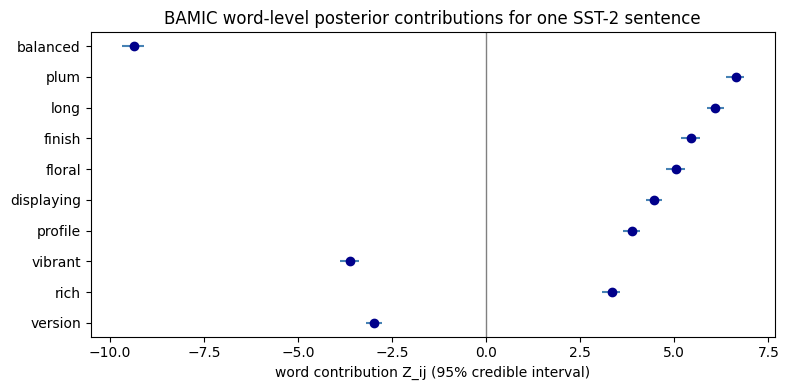

In [46]:
# ================================================================
# 18. Plot posterior intervals for the word contributions
# ================================================================

# Take the ten words with the largest absolute mean contribution.
top = word_table.head(10).iloc[::-1]

# Draw a horizontal interval plot: one line per word.
plt.figure(figsize=(8, 4))
# The horizontal line spans the 95% credible interval of each word's contribution.
plt.hlines(y=range(len(top)), xmin=top['z_ci95_lo'], xmax=top['z_ci95_hi'], color='steelblue')
# The dot marks the posterior mean contribution.
plt.plot(top['z_mean'], range(len(top)), 'o', color='darkblue')
# A vertical line at zero separates negative from positive contributions.
plt.axvline(0.0, color='gray', linewidth=1)
# Label each row with its word.
plt.yticks(range(len(top)), top['word'])
plt.xlabel('word contribution Z_ij (95% credible interval)')
plt.title('BAMIC word-level posterior contributions for one SST-2 sentence')
plt.tight_layout()
# Save the figure into the output folder for the paper.
plt.savefig(OUTPUT_DIR / 'example_word_contribution_intervals.png', dpi=150)
plt.show()

In [47]:
# ================================================================
# 19. Corpus-level word sentiment table (validation split)
# ================================================================

# Number of posterior samples per batch for the corpus scan.
CORPUS_MC_SAMPLES = 20

# Accumulate per-word statistics across the validation split.
word_stats = {}

with torch.no_grad():
    # Eval mode keeps dropout off.
    model.eval()
    # Walk over validation batches.
    for batch in valid_loader:
        # Move ids to the GPU.
        input_ids = batch['input_ids'].to(DEVICE)
        # Average delta and Z over posterior samples for this batch.
        delta_sum = torch.zeros(input_ids.shape, dtype=torch.float32)
        z_sum = torch.zeros(input_ids.shape, dtype=torch.float32)
        for _ in range(CORPUS_MC_SAMPLES):
            out = model(input_ids, sample=True)
            delta_sum += out['delta'].cpu()
            z_sum += out['word_logit'].cpu()
        delta_mean = (delta_sum / CORPUS_MC_SAMPLES).numpy()
        z_mean = (z_sum / CORPUS_MC_SAMPLES).numpy()
        # Accumulate statistics per vocabulary word.
        ids = input_ids.cpu().numpy()
        for i in range(ids.shape[0]):
            for j in range(ids.shape[1]):
                # Skip padding.
                if ids[i, j] == 0:
                    break
                word = id_to_word.get(int(ids[i, j]), '<UNK>')
                stats = word_stats.setdefault(word, {'count': 0, 'delta_sum': 0.0, 'z_sum': 0.0})
                stats['count'] += 1
                stats['delta_sum'] += float(delta_mean[i, j])
                stats['z_sum'] += float(z_mean[i, j])

# Convert the accumulated statistics into a table (words seen at least 5 times).
corpus_rows = []
for word, stats in word_stats.items():
    if stats['count'] >= 5:
        corpus_rows.append({
            'word': word,
            'count': stats['count'],
            'delta_mean': stats['delta_sum'] / stats['count'],
            'z_mean': stats['z_sum'] / stats['count'],
        })

# Sort by absolute average contribution so the strongest sentiment words appear first.
corpus_table = pd.DataFrame(corpus_rows).sort_values('z_mean', key=np.abs, ascending=False)

# Count how many of the top-100 words are penalized stopwords (contamination check).
top100 = corpus_table.head(100)
stopword_contamination = int(top100['word'].isin(STOPWORD_PENALTY_WORDS).sum())
print('Stopword contamination in top-100 corpus words:', stopword_contamination)

# Save the corpus-level table for the paper.
corpus_table.to_csv(OUTPUT_DIR / 'corpus_word_sentiment.csv', index=False)

# Display the strongest 20 words.
corpus_table.head(20)

Stopword contamination in top-100 corpus words: 1


,word,count,delta_mean,z_mean
1254,quick,5,0.980024,-14.499076
213,scale,6,0.988416,-14.467771
207,simple,21,0.991015,-14.189791
882,herbaceous,5,0.988668,-13.622365
475,rustic,49,0.979198,-13.373800
188,astringent,13,0.986644,-12.999935
767,austere,41,0.983489,-12.648214
1143,shadings,5,0.995117,-12.247713
708,chive,10,0.980030,-12.168361
619,basic,5,0.965594,-12.059497


In [48]:
# ================================================================
# 22. Save final metrics and the run configuration
# ================================================================

# Collect one metrics row per split so the comparison table can read them later.
final_metric_rows = []

# Loop over the three splits with their posterior-mean probabilities and true labels.
for split_name, probs, labels in [('train', train_probs, y_train_true),
                                  ('valid', valid_probs, y_valid_true),
                                  ('test', test_probs, y_test_true)]:
    # Compute accuracy, F1, AUC, Brier, and NLL for this split.
    metrics = binary_metrics_from_probs(probs, labels)
    # Compute the calibration error for this split.
    ece = expected_calibration_error(probs, labels)
    # Store everything in one row.
    final_metric_rows.append({'split': split_name, **metrics, 'ece': ece})
    # Print the row so we can see the result immediately.
    print(split_name, {k: round(v, 4) for k, v in metrics.items()}, 'ece=', round(ece, 4))

# Convert the rows into a small dataframe and save it.
pd.DataFrame(final_metric_rows).to_csv(OUTPUT_DIR / 'final_metrics.csv', index=False)

# Also record the exact run configuration for reproducibility.
pd.DataFrame([{
    'freeze_embeddings': FREEZE_EMBEDDINGS,
    'epochs': ABLATION_EPOCHS,
    'num_heads': NUM_HEADS,
    'lambda_boilerplate': LAMBDA_BOILERPLATE,
    'lambda_stopword': LAMBDA_STOPWORD,
    'stopword_warmup_epochs': STOPWORD_WARMUP_EPOCHS,
    'learning_rate': BAMIC_LEARNING_RATE,
    'max_len': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'best_acc_threshold': best_acc_threshold,
    'best_f1_threshold': best_f1_threshold,
}]).to_csv(OUTPUT_DIR / 'run_config.csv', index=False)

# Save the model weights so the run can be reloaded without retraining.
torch.save(model.state_dict(), OUTPUT_DIR / 'bamic_wine_state_dict.pt')

# Confirm where everything was written.
print('Saved final_metrics.csv, threshold_tuning.csv, run_config.csv, and weights to:', OUTPUT_DIR)

train {'acc': 0.8721, 'f1': 0.8303, 'auc': np.float64(0.9558), 'brier': np.float64(0.0885), 'nll': 0.2793} ece= 0.065
valid {'acc': 0.8503, 'f1': 0.8009, 'auc': np.float64(0.9412), 'brier': np.float64(0.1004), 'nll': 0.3097} ece= 0.0596
test {'acc': 0.8585, 'f1': 0.8117, 'auc': np.float64(0.9418), 'brier': np.float64(0.0994), 'nll': 0.3111} ece= 0.0621
Saved final_metrics.csv, threshold_tuning.csv, run_config.csv, and weights to: /content/drive/MyDrive/AMIC project/wine_benchmark/outputs/wine_bamic_frozen_ep15_heads1_lamB0p1_lamS0p01_len100
